In [6]:
# load lib
library(tidyverse)
county_data <- read.csv("data/county_data.csv")
census_data <- read.csv("data/texas_census.csv")
brfss_data <- read.csv("data/brfss_data.csv")

In [7]:
county_data <- county_data %>%
  left_join(census_data, by = "County")

# # Verify merge worked
county_data %>%
  summarise(
    n_counties        = n(),
    missing_hispanic  = sum(is.na(pct_hispanic)),
    missing_poverty   = sum(is.na(pct_poverty)),
    missing_uninsured = sum(is.na(pct_uninsured))
  )
nacounty <- county_data[!complete.cases(county_data), ]
print(nacounty)

n_counties,missing_hispanic,missing_poverty,missing_uninsured
<int>,<int>,<int>,<int>
254,4,4,4


           County   cve outbreak enrollment PHR pct_hispanic pct_black
1        Anderson  2.54        0       7808   4         19.6      18.6
2         Andrews  1.91        3       4209   9         57.5       1.6
3        Angelina  2.50        0      15649   5         23.5      12.1
4         Aransas  2.06        0       2913  11         27.1       1.3
5          Archer  2.70        0       2110   2          9.4       1.5
6       Armstrong  5.24        0        297   1         12.0       0.6
7        Atascosa  1.08        1       9046   8         65.4       1.2
8          Austin  3.55        0       6290   6         27.8       7.9
9          Bailey  0.80        2       1330   1         66.0       0.9
10        Bandera  3.78        0       2461   8         21.0       1.2
11        Bastrop  2.09        0      21555   7         45.0       5.8
12         Baylor  0.88        0        594   2         13.1       1.2
13            Bee  1.48        0       5097  11         61.8       7.3
14    

In [8]:
county_data <- county_data %>%
  left_join(brfss_data, by = "PHR")

In [9]:
county_data %>% 
  select(County, PHR, cve, 
         medical_cost_pct, flu_shot_pct) %>% 
  head(10)


,County,PHR,cve,medical_cost_pct,flu_shot_pct
,<chr>,<int>,<dbl>,<dbl>,<dbl>
1,Anderson,4,2.54,21.6,38.9
2,Andrews,9,1.91,16.8,25.2
3,Angelina,5,2.50,18.1,29.3
4,Aransas,11,2.06,16.9,25.2
5,Archer,2,2.70,20.9,38.5
6,Armstrong,1,5.24,20.0,32.5
7,Atascosa,8,1.08,18.6,31.6
8,Austin,6,3.55,17.3,30.4
9,Bailey,1,0.80,20.0,32.5


In [10]:
library(lme4)
model_full <- glmer(
  outbreak ~
    # BRFSS PHR-level variables
    scale(medical_cost_pct) +
    scale(flu_shot_pct) +
    scale(cve) +
    # Census county-level proxies for suppressed BRFSS groups
    scale(pct_hispanic) +
    scale(pct_black) +
    scale(pct_poverty) +
    scale(pct_uninsured) +
    scale(pct_college) +
    
    # Offset
    offset(log(enrollment)) +
    
    # Random effects
    (1 | PHR) +
    # (1 | PHR:County),
    
  family = poisson,
  data = county_data,
  nAGQ = 0
)
summary(model_full)

ERROR: Error in parse(text = x, srcfile = src): <text>:22:10: Unerwartete(s) '='
21:     
22:   family =
             ^


In [ ]:
model_measles <- glmer(
  outbreak ~
    # scale(medical_cost_pct) +
    # scale(flu_shot_pct) +
    scale(cve) +
    scale(pct_uninsured) +
    scale(pct_college) +
    offset(log(enrollment)) +
    (1 | PHR),
    
  family = poisson,
  data = county_data,
  control = glmerControl(optimizer = "bobyqa",
                       optCtrl = list(maxfun = 1e6)) 
)
summary(model_measles)


ERROR: Error in glmer(outbreak ~ scale(cve) + scale(pct_uninsured) + scale(pct_college) + : konnte Funktion "glmer" nicht finden


In [11]:
library(glmmTMB)

model_measles <- glmmTMB(
  outbreak ~ scale(medical_cost_pct)  + scale(cve) + scale(pct_uninsured) + scale(pct_black)+
    offset(log(enrollment)) +
    (1 | PHR),
  family = nbinom2,  # directly models overdispersion
  data = county_data
)
summary(model_measles)

Warning message:
"Paket 'glmmTMB' wurde unter R Version 4.4.3 erstellt"


 Family: nbinom2  ( log )
Formula:          
outbreak ~ scale(medical_cost_pct) + scale(cve) + scale(pct_uninsured) +  
    scale(pct_black) + offset(log(enrollment)) + (1 | PHR)
Data: county_data

      AIC       BIC    logLik -2*log(L)  df.resid 
    374.3     398.9    -180.2     360.3       242 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 PHR    (Intercept) 3.539    1.881   
Number of obs: 249, groups:  PHR, 11

Dispersion parameter for nbinom2 family (): 0.161 

Conditional model:
                        Estimate Std. Error z value Pr(>|z|)    
(Intercept)             -10.9917     0.8153 -13.482  < 2e-16 ***
scale(medical_cost_pct)   2.1538     0.9067   2.375  0.01753 *  
scale(cve)                0.6292     0.3496   1.799  0.07195 .  
scale(pct_uninsured)      0.7500     0.2740   2.738  0.00619 ** 
scale(pct_black)         -0.7262     0.4747  -1.530  0.12605    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

In [12]:
summary(county_data$enrollment)
any(county_data$enrollment <= 0, na.rm = TRUE)

summary(county_data$cve)
any(!is.finite(county_data$cve))
any(county_data$cve < 0, na.rm = TRUE)
any(abs(county_data$cve - round(county_data$cve)) > 1e-8, na.rm = TRUE)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
     93    1180    3240   22023   10549  879002       5 

[1] FALSE

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   1.492   2.490   2.817   3.765  14.540 

[1] FALSE

[1] FALSE

[1] TRUE

In [13]:
library(lme4)

d <- subset(county_data, is.finite(cve))
d <- droplevels(d)

model_gauss <- lmer(
  cve ~
    scale(medical_cost_pct) +
    scale(flu_shot_pct) +
    scale(pct_hispanic) +
    scale(pct_black) +
    scale(pct_poverty) +
    scale(pct_uninsured) +
    scale(pct_college) +
    (1 | PHR),
  data = d,
  REML = TRUE
)

summary(model_gauss)

Warning message:
"Paket 'lme4' wurde unter R Version 4.4.3 erstellt"
Lade n"otiges Paket: Matrix


Attache Paket: 'Matrix'


Die folgenden Objekte sind maskiert von 'package:tidyr':

    expand, pack, unpack




Linear mixed model fit by REML ['lmerMod']
Formula: 
cve ~ scale(medical_cost_pct) + scale(flu_shot_pct) + scale(pct_hispanic) +  
    scale(pct_black) + scale(pct_poverty) + scale(pct_uninsured) +  
    scale(pct_college) + (1 | PHR)
   Data: d

REML criterion at convergence: 944.3

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.4379 -0.4878 -0.1125  0.3984  6.2658 

Random effects:
 Groups   Name        Variance Std.Dev.
 PHR      (Intercept) 0.1686   0.4106  
 Residual             2.3673   1.5386  
Number of obs: 250, groups:  PHR, 11

Fixed effects:
                        Estimate Std. Error t value
(Intercept)              2.75332    0.16189  17.008
scale(medical_cost_pct)  0.10803    0.18625   0.580
scale(flu_shot_pct)     -0.19760    0.18977  -1.041
scale(pct_hispanic)     -1.32241    0.15740  -8.402
scale(pct_black)        -0.49140    0.11883  -4.135
scale(pct_poverty)      -0.02286    0.12369  -0.185
scale(pct_uninsured)     0.51998    0.12487   4.164
scale(pc

In [14]:
library(glmmTMB)

model_measles <- glmmTMB(
  flu_shot_pct ~ scale(medical_cost_pct) + scale(pct_uninsured) + scale(pct_hispanic) +
    # offset(log(enrollment)) +
    (1 | PHR),
  family = nbinom2,  # directly models overdispersion
  data = county_data
)
summary(model_measles)

Warning message in glmmTMB(flu_shot_pct ~ scale(medical_cost_pct) + scale(pct_uninsured) + :
"non-integer counts in a nbinom2 model"


 Family: nbinom2  ( log )
Formula:          
flu_shot_pct ~ scale(medical_cost_pct) + scale(pct_uninsured) +  
    scale(pct_hispanic) + (1 | PHR)
Data: county_data

      AIC       BIC    logLik -2*log(L)  df.resid 
   1377.7    1398.8    -682.8    1365.7       244 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 PHR    (Intercept) 0.0137   0.1171  
Number of obs: 250, groups:  PHR, 11

Dispersion parameter for nbinom2 family (): 9.52e+07 

Conditional model:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)              3.462833   0.037499   92.35   <2e-16 ***
scale(medical_cost_pct)  0.054061   0.040085    1.35    0.177    
scale(pct_uninsured)     0.001253   0.014106    0.09    0.929    
scale(pct_hispanic)     -0.013086   0.019003   -0.69    0.491    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

In [15]:
# 你现在的模型（普通NB）
model_nb <- glmmTMB(
  outbreak ~ scale(cve) + scale(medical_cost_pct) +
             offset(log(enrollment)) + (1 | PHR),
  family = nbinom2,
  data = county_data
)

# ZINB：多一个 ziformula
model_zinb <- glmmTMB(
  outbreak ~ scale(cve) + scale(medical_cost_pct) +
             offset(log(enrollment)) + (1 | PHR),

  ziformula = ~ scale(enrollment) + scale(cve),
  # ↑ 用enrollment预测"是否结构性0"
  # 学生越少 → 越可能是结构性0

  family = nbinom2,
  data = county_data
)

# 比较哪个更好
AIC(model_nb, model_zinb)
# AIC差>10 → 用ZINB
# AIC差<10 → 普通NB够用，更简洁

Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
"Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')"


,df,AIC
,<dbl>,<dbl>
model_nb,5,380.7080
model_zinb,8,383.9676


In [16]:
library(tidyverse)
library(glmmTMB)

# ── 1. 读入合并好的数据 ──────────────────────────────
county_full <- county_data

# ── 2. 最终模型 ──────────────────────────────────────
model_final <- glmmTMB(
  outbreak ~
    scale(cve) +
    scale(pct_uninsured) +
    scale(pct_hispanic) +
    scale(pct_black) +
    scale(medical_cost_pct) +    # PHR级别
    scale(flu_shot_pct) +        # PHR级别
    offset(log(enrollment)) +
    (1 | PHR),
  family = nbinom2,
  data = county_full
)

summary(model_final)

# ── 3. 转换为IRR（Incidence Rate Ratio）──────────────
results <- broom.mixed::tidy(model_final, 
                              conf.int = TRUE, 
                              exponentiate = TRUE) %>%
  filter(effect == "fixed") %>%
  select(term, estimate, conf.low, conf.high, p.value) %>%
  mutate(across(where(is.numeric), ~round(., 3)))

print(results)

# ── 4. 模型诊断 ───────────────────────────────────────
# 检查随机效应
ranef(model_final)

# 检查那个极端值 (outbreak=414)
county_full %>% filter(outbreak == max(outbreak, na.rm=T))

# 敏感性分析：去掉极端值后结果是否稳定
model_sensitivity <- glmmTMB(
  outbreak ~
    scale(cve) + scale(pct_uninsured) +
    scale(pct_hispanic) + scale(pct_black) +
    scale(medical_cost_pct) + scale(flu_shot_pct) +
    offset(log(enrollment)) + (1 | PHR),
  family = nbinom2,
  data = county_full %>% filter(outbreak < 414)
)

# 比较主要结果是否变化
summary(model_sensitivity)

 Family: nbinom2  ( log )
Formula:          
outbreak ~ scale(cve) + scale(pct_uninsured) + scale(pct_hispanic) +  
    scale(pct_black) + scale(medical_cost_pct) + scale(flu_shot_pct) +  
    offset(log(enrollment)) + (1 | PHR)
Data: county_full

      AIC       BIC    logLik -2*log(L)  df.resid 
    377.8     409.5    -179.9     359.8       240 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 PHR    (Intercept) 3.478    1.865   
Number of obs: 249, groups:  PHR, 11

Dispersion parameter for nbinom2 family (): 0.162 

Conditional model:
                        Estimate Std. Error z value Pr(>|z|)    
(Intercept)             -11.0561     0.8313 -13.299   <2e-16 ***
scale(cve)                0.7614     0.4057   1.877   0.0605 .  
scale(pct_uninsured)      0.6236     0.3357   1.858   0.0632 .  
scale(pct_hispanic)       0.3534     0.5672   0.623   0.5332    
scale(pct_black)         -0.6667     0.4832  -1.380   0.1677    
scale(medical_cost_pct)   2.3251     1

ERROR: Error in loadNamespace(x): es gibt kein Paket namens 'broom.mixed'


In [17]:
# 考虑从最终模型里去掉，用AIC验证
model_no_flu <- glmmTMB(
  outbreak ~ scale(cve) + scale(pct_uninsured) +
             scale(pct_hispanic) + scale(pct_black) +
             scale(medical_cost_pct) +
             offset(log(enrollment)) + (1 | PHR),
  family = nbinom2,
  data = county_full
)

AIC(model_final, model_no_flu)
# 如果no_flu的AIC更低 → 删掉flu_shot更好

,df,AIC
,<dbl>,<dbl>
model_final,9,377.8060
model_no_flu,8,375.8178


In [18]:
county_full %>% filter(outbreak == 414) %>%
  select(County, PHR, outbreak, enrollment, cve, medical_cost_pct)

County,PHR,outbreak,enrollment,cve,medical_cost_pct
<chr>,<int>,<int>,<int>,<dbl>,<dbl>
Gaines,1,414,3764,14.54,20


In [19]:
# 去掉Gaines County，看core finding是否稳健
model_sensitivity <- glmmTMB(
  outbreak ~ scale(cve) + scale(pct_uninsured) +
             scale(pct_hispanic) + scale(pct_black) +
             scale(medical_cost_pct) +
             offset(log(enrollment)) + (1 | PHR),
  family = nbinom2,
  data = county_full %>% filter(County != "Gaines")
)

summary(model_sensitivity)

 Family: nbinom2  ( log )
Formula:          
outbreak ~ scale(cve) + scale(pct_uninsured) + scale(pct_hispanic) +  
    scale(pct_black) + scale(medical_cost_pct) + offset(log(enrollment)) +  
    (1 | PHR)
Data: county_full %>% filter(County != "Gaines")

      AIC       BIC    logLik -2*log(L)  df.resid 
    358.8     387.0    -171.4     342.8       240 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 PHR    (Intercept) 3.382    1.839   
Number of obs: 248, groups:  PHR, 11

Dispersion parameter for nbinom2 family (): 0.155 

Conditional model:
                        Estimate Std. Error z value Pr(>|z|)    
(Intercept)             -11.0697     0.8237 -13.439   <2e-16 ***
scale(cve)                0.8422     0.4137   2.036   0.0418 *  
scale(pct_uninsured)      0.6579     0.3358   1.959   0.0501 .  
scale(pct_hispanic)       0.4010     0.5420   0.740   0.4594    
scale(pct_black)         -0.6461     0.4912  -1.315   0.1883    
scale(medical_cost_pct)   2.2

03092026

In [20]:
population_data <- read_csv("data/population.csv")
summary(population_data)
county_data <- county_data %>% 
  left_join(population_data, by = "County") %>% 
  rename(population = `2025_pop`)
summary(county_data)
colnames(county_data)

Rows: 254 Columns: 2
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (1): County
dbl (1): 2025_pop

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


    County             2025_pop      
 Length:254         Min.   :     55  
 Class :character   1st Qu.:   6389  
 Mode  :character   Median :  19718  
                    Mean   : 124300  
                    3rd Qu.:  56581  
                    Max.   :5003892  

    County               cve            outbreak         enrollment    
 Length:254         Min.   : 0.000   Min.   :  0.000   Min.   :    93  
 Class :character   1st Qu.: 1.492   1st Qu.:  0.000   1st Qu.:  1180  
 Mode  :character   Median : 2.490   Median :  0.000   Median :  3240  
                    Mean   : 2.817   Mean   :  2.925   Mean   : 22023  
                    3rd Qu.: 3.765   3rd Qu.:  0.000   3rd Qu.: 10549  
                    Max.   :14.540   Max.   :414.000   Max.   :879002  
                                                       NA's   :5       
      PHR          pct_hispanic     pct_black       pct_white    
 Min.   : 1.000   Min.   : 0.00   Min.   : 0.00   Min.   :14.40  
 1st Qu.: 2.000   1st Qu.:19.30   1st Qu.: 1.20   1st Qu.:55.17  
 Median : 5.000   Median :27.65   Median : 3.95   Median :66.10  
 Mean   : 5.323   Mean   :35.63   Mean   : 6.02   Mean   :63.94  
 3rd Qu.: 8.000   3rd Qu.:50.02   3rd Qu.: 8.20   3rd Qu.:76.22  
 Max.   :11.000   Max.   :97

[1] "County"             "cve"                "outbreak"          
 [4] "enrollment"         "PHR"                "pct_hispanic"      
 [7] "pct_black"          "pct_white"          "pct_poverty"       
[10] "pct_uninsured"      "pct_college"        "median_income"     
[13] "pct_foreign_born"   "medical_cost_pct"   "flu_shot_pct"      
[16] "pneumonia_shot_pct" "routine_check_pct"  "population"

In [21]:
library(tidyverse)

# Step 1: 聚合ACS到PHR级别（按enrollment加权）
phr_acs <- county_data %>%
  group_by(PHR) %>%
  summarise(
    pct_uninsured = weighted.mean(pct_uninsured, enrollment, na.rm = TRUE),
    pct_poverty   = weighted.mean(pct_poverty,   enrollment, na.rm = TRUE),
    pct_college   = weighted.mean(pct_college,   enrollment, na.rm = TRUE)
  )

# Step 2: 合并BRFSS
phr_data <- phr_acs %>%
  left_join(brfss_data %>% select(PHR, medical_cost_pct), by = "PHR")

# Step 3: 在PHR级别拟合线性模型
# (只有11行，用这个关系外推到county)
sae_model <- lm(
  medical_cost_pct ~ pct_college + pct_poverty + pct_uninsured,
  data = phr_data
)
summary(sae_model)  # R² = 0.449

# Step 4: 用county级别ACS变量预测
county_data <- county_data %>%
  mutate(
    medical_cost_sae = predict(sae_model, newdata = county_data),
    medical_cost_sae = pmax(pmin(medical_cost_sae, 23.6), 11.0)  # clip到合理范围
  )

# Step 5: 对比PHR均值 vs BRFSS实际值（sanity check）
county_data %>%
  group_by(PHR) %>%
  summarise(sae_mean = mean(medical_cost_sae, na.rm = TRUE)) %>%
  left_join(brfss_data %>% select(PHR, medical_cost_pct), by = "PHR")

head(county_data %>% select(County, medical_cost_sae))


Call:
lm(formula = medical_cost_pct ~ pct_college + pct_poverty + pct_uninsured, 
    data = phr_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.36680 -0.89087 -0.02538  0.92092  2.13514 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)    30.4462     4.6524   6.544 0.000609 ***
pct_college    -0.3897     0.1087  -3.584 0.011589 *  
pct_poverty    -0.8987     0.5357  -1.678 0.144430    
pct_uninsured   0.5579     0.4834   1.154 0.292352    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1.667 on 6 degrees of freedom
  (1 Beobachtung als fehlend gel"oscht)
Multiple R-squared:  0.7084,	Adjusted R-squared:  0.5625 
F-statistic: 4.858 on 3 and 6 DF,  p-value: 0.04793


PHR,sae_mean,medical_cost_pct
<int>,<dbl>,<dbl>
1,20.91149,20.0
2,20.70320,20.9
3,20.00870,16.6
4,21.47890,21.6
5,20.92612,18.1
6,19.31455,17.3
7,20.04417,13.0
8,18.73655,18.6
9,22.47233,16.8


,County,medical_cost_sae
,<chr>,<dbl>
1,Anderson,22.63208
2,Andrews,23.28229
3,Angelina,23.00904
4,Aransas,16.74677
5,Archer,23.60000
6,Armstrong,16.79682


In [22]:
model_sae <- glmmTMB(
  outbreak ~ scale(cve) + scale(pct_uninsured) +
             scale(pct_hispanic) + scale(pct_black) +
             scale(medical_cost_sae) +
             (1 | PHR),
  family = nbinom2,
  data = county_data
)

summary(model_sae)

 Family: nbinom2  ( log )
Formula:          
outbreak ~ scale(cve) + scale(pct_uninsured) + scale(pct_hispanic) +  
    scale(pct_black) + scale(medical_cost_sae) + (1 | PHR)
Data: county_data

      AIC       BIC    logLik -2*log(L)  df.resid 
    400.3     428.5    -192.2     384.3       242 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 PHR    (Intercept) 5.984    2.446   
Number of obs: 250, groups:  PHR, 11

Dispersion parameter for nbinom2 family (): 0.11 

Conditional model:
                        Estimate Std. Error z value Pr(>|z|)  
(Intercept)              -1.9580     0.9561  -2.048   0.0406 *
scale(cve)                0.4382     0.3621   1.210   0.2262  
scale(pct_uninsured)      0.7096     0.4309   1.647   0.0996 .
scale(pct_hispanic)       0.7076     0.6324   1.119   0.2631  
scale(pct_black)          0.2421     0.5835   0.415   0.6782  
scale(medical_cost_sae)  -0.6027     0.3619  -1.665   0.0959 .
---
Signif. codes:  0 '***' 0.001 '**' 0.0

In [23]:
model_final <- glmmTMB(
  outbreak ~ scale(cve) + scale(pct_uninsured) +
             scale(pct_hispanic) + scale(pct_black) +
             scale(medical_cost_pct) +
             offset(log(population)) +
             (1 | PHR),
  family = nbinom2,
  data = county_data
)
summary(model_final)

 Family: nbinom2  ( log )
Formula:          
outbreak ~ scale(cve) + scale(pct_uninsured) + scale(pct_hispanic) +  
    scale(pct_black) + scale(medical_cost_pct) + offset(log(population)) +  
    (1 | PHR)
Data: county_data

      AIC       BIC    logLik -2*log(L)  df.resid 
    375.3     403.5    -179.6     359.3       242 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 PHR    (Intercept) 3.796    1.948   
Number of obs: 250, groups:  PHR, 11

Dispersion parameter for nbinom2 family (): 0.165 

Conditional model:
                        Estimate Std. Error z value Pr(>|z|)    
(Intercept)             -12.8329     0.8444 -15.197   <2e-16 ***
scale(cve)                0.8341     0.4144   2.013   0.0441 *  
scale(pct_uninsured)      0.5696     0.3345   1.703   0.0886 .  
scale(pct_hispanic)       0.4997     0.5381   0.929   0.3531    
scale(pct_black)         -0.7557     0.4822  -1.567   0.1171    
scale(medical_cost_pct)   2.3092     0.9478   2.436   0.0148

\subsubsection{Extended Model with BRFSS Controls}
The baseline negative binomial model establishes a robust association between conscientious exemption rates and measles outbreak risk with accounting for population size, but omits socioeconomic and healthcare access factors that may confound this relationship. Counties with higher exemption rates may have less access to healthcare and higher uninsured rates, which could independently increase outbreak risk and bias the $\hat{\beta}_1$ estimate.

To better address potential confounding, we extend the base model by incorporating additional covariates that capture healthcare access and socialeconomic characters at county and public health region(PHR) levels. County-level data on health insurance coverage, demographic compositions and education levels are derived from the American Community Survey (ACS) 5-year estimates for 2020-2024, accessed via the US Census Bureau's API. More health behavior and access to care variables are obtained from the Behavioral Risk Factor Surveillance System (BRFSS), an annual cross-sectional telephone survey administered by the CDC. We included 3 additional county-level covariates: percentage of noninstitutionalized civilians with no health insurance coverage ($\text{Unins}_c$), percentage of total population in each county identifying as Hispanic or multiracial ($\text{Hisp}_c$), percentage identifying as Black or multiracial ($\text{Black}_c$), and 1 additional PHR-level covariate: percentage of adults in the survey reporting that medical costs prevented them from seeing a doctor in the past year ($\text{MedCost}_r$).

To account for the different magnitude of these new covariates compared to the CVE rate, all predictors are standardized using z-score scaling which allows direct comparison of effect sizes across variables in terms of changes in standard deviations. Additionally, $\text{MedCost}_r$ is a PHR-level variable and 2025 outbreak is geographically clustered, so we introduce a random intercept for PHR to account for unobserved regional factors such as transmission dynamics. The random effect isolates the influence of CVE and other covariates on outbreak risk within regions. The extended model can be expressed as:

\begin{equation}
Y_c \sim \text{NegBin}(\mu_c, \theta),
\end{equation}

\begin{equation}
\log(\mu_c) = \alpha + \beta_1 \widetilde{\CVE}_c 
+ \beta_2 \widetilde{\text{Unins}}_c 
+ \beta_3 \widetilde{\text{Hisp}}_c 
+ \beta_4 \widetilde{\text{Black}}_c 
+ \beta_5 \widetilde{\text{MedCost}}_c 
+ \log(\text{Pop}_c) + (1 | \text{PHR}_r)
\end{equation}

where tildes denote standardized variables, $u_r \sim 
\mathcal{N}(0, \sigma^2_r)$ is the PHR-level random intercept, and 
the offset $\log(\text{Pop}_c)$ adjusts for county population size 
as before.

\begin{table}[H]
\centering
\caption{Extended Negative Binomial Regression of Measles Outbreak 
Rates with BRFSS Controls, 2025}
\label{tab:extended}
\begin{tabular}{l c c}
\hline
 & (1) & (2) \\
 & Baseline & Extended \\
\hline
Conscientious Exemption Rate
    & 0.4903*** & 0.8341* \\
    & (0.1571)  & (0.4144) \\

Uninsured Rate
    &           & 0.5696. \\
    &           & (0.3345) \\

Percent Hispanic
    &           & 0.4997 \\
    &           & (0.5381) \\

Percent Black
    &           & $-$0.7557 \\
    &           & (0.4822) \\

Medical Cost Barrier
    &           & 2.3092* \\
    &           & (0.9478) \\

Constant
    & $-$9.7723*** & $-$12.8329*** \\
    & (0.3135)     & (0.8444)  \\
\hline
Population Offset   & Yes  & Yes \\
PHR Random Effect   & No   & Yes \\
County Observations & 249  & 250 \\
Dispersion $\hat{\theta}$ & 0.046 & 0.165 \\
AIC                 & 420.21 & 375.30 \\
\hline
\multicolumn{3}{l}{\footnotesize Standard errors in parentheses.} \\
\multicolumn{3}{l}{\footnotesize *** $p<0.01$, ** $p<0.05$, 
    * $p<0.05$, . $p<0.1$.} \\
\end{tabular}
\end{table}

Table \ref{tab:extended} presents results from both specifications. 
The coefficient on conscientious exemption rate in the extended model 
is $\hat{\beta}_1 = 0.8341$, statistically significant at the 5\% 
level ($p = 0.044$). Exponentiating this coefficient yields an 
incidence rate ratio of $\exp(0.8341) \approx 2.30$, implying that 
a one standard deviation increase in the exemption rate is associated 
with approximately a 130\% increase in the expected measles outbreak 
rate, holding all other covariates constant. The stability of the 
CVE coefficient across specifications — from the baseline model 
through the inclusion of demographic and healthcare controls and 
a regional random effect — provides evidence that the association 
is not driven by socioeconomic confounding.

The coefficient on medical cost barrier is $\hat{\beta}_5 = 2.3092$ 
($p = 0.015$), suggesting that counties where residents more 
frequently forgo care due to cost face meaningfully higher outbreak 
risk. This finding is consistent with a healthcare avoidance 
mechanism operating independently of vaccination behavior. The 
uninsured rate approaches conventional significance ($p = 0.089$), 
suggesting a complementary role for insurance coverage, though 
the evidence is not conclusive at standard thresholds. Demographic 
controls for the share of Hispanic and Black residents are not 
statistically significant after accounting for regional clustering.

The estimated PHR random effect variance is $\hat{\sigma}^2_r = 
3.796$ (SD = 1.948), indicating substantial heterogeneity in 
baseline outbreak risk across Texas Public Health Regions that 
is not captured by county-level covariates alone. This likely 
reflects regional differences in public health infrastructure, 
outbreak response capacity, and community-level transmission 
dynamics. The dispersion parameter increased from $\hat{\theta} 
= 0.046$ in the baseline to $\hat{\theta} = 0.165$ in the 
extended model, and AIC improved from 420.21 to 375.30, 
confirming that the extended specification provides a 
substantially better fit to the data.

One of the key concerns with the extended model is that the CVE coefficient may be influenced by counties with extreme outbreak sizes. To account for extreme values, we re-estimate the extended model by excluding counties with over 50 reported measles cases. After removing 4 extreme counties, the CVE coefficient increases from 0.834 to 1.064 with $p = 0.015$, which suggests the correlation between CVE and outbreak risk is even stronger when outliers are removed, which verifies the robustness of our results. 

We also noticed that except for a few counties, the majority of counties in Texas had zero reported measles cases in 2025, which could either reflect a true absence of outbreaks because of its location or high vaccination coverage, or the county never encountered infected individuals. To understand which is more likely, we applied zero-inflated negative binomial regression to the extended model to account for the excess zeros, which has $\text{AIC} = 377.29$ compared to $\text{AIC} = 375.30$ for the standard negative binomial model, indicating that the standard model provides a better fit to the data without needing a separate zero-inflation component. This suggests that most of the zero counts county are in principle susceptible to outbreaks but did not experience them in 2025. 

In [24]:
county_data_trim <- county_data %>% filter(outbreak < 50) # adjust threshold
model_trim <- update(model_final, data = county_data_trim)
summary(model_trim)

 Family: nbinom2  ( log )
Formula:          
outbreak ~ scale(cve) + scale(pct_uninsured) + scale(pct_hispanic) +  
    scale(pct_black) + scale(medical_cost_pct) + offset(log(population)) +  
    (1 | PHR)
Data: county_data_trim

      AIC       BIC    logLik -2*log(L)  df.resid 
    316.9     344.9    -150.4     300.9       238 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 PHR    (Intercept) 3.54     1.882   
Number of obs: 246, groups:  PHR, 11

Dispersion parameter for nbinom2 family (): 0.149 

Conditional model:
                        Estimate Std. Error z value Pr(>|z|)    
(Intercept)             -12.9826     0.8603 -15.091   <2e-16 ***
scale(cve)                1.0644     0.4355   2.444   0.0145 *  
scale(pct_uninsured)      0.6087     0.3798   1.603   0.1090    
scale(pct_hispanic)       0.5135     0.5723   0.897   0.3696    
scale(pct_black)         -0.7602     0.4886  -1.556   0.1198    
scale(medical_cost_pct)   2.1733     0.9417   2.308   0

In [25]:
model_zinfl <- glmmTMB(
  outbreak ~ scale(cve) + scale(pct_uninsured) +
             scale(pct_hispanic) + scale(pct_black) +
             scale(medical_cost_pct) +
             offset(log(population)) + (1 | PHR),
  ziformula = ~1,
  family = nbinom2,
  data = county_data
)
AIC(model_final, model_zinfl)

,df,AIC
,<dbl>,<dbl>
model_final,8,375.2864
model_zinfl,9,377.2864


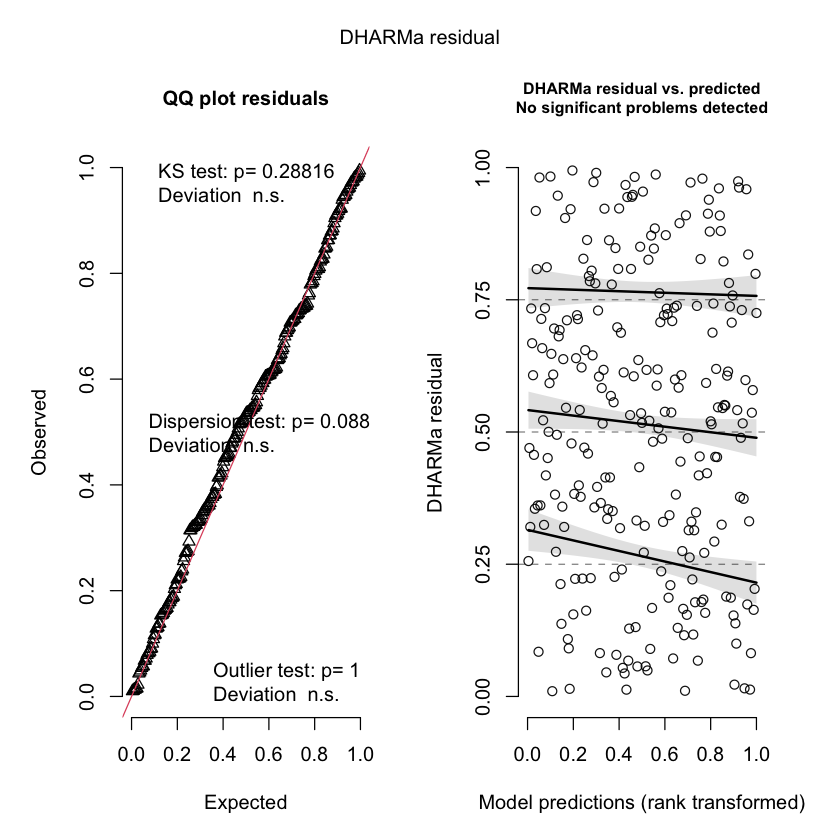


	DHARMa bootstrapped outlier test

data:  sim_res
outliers at both margin(s) = 0, observations = 250, p-value = 1
alternative hypothesis: two.sided
 percent confidence interval:
 0.000 0.004
sample estimates:
outlier frequency (expected: 0.00084 ) 
                                     0 


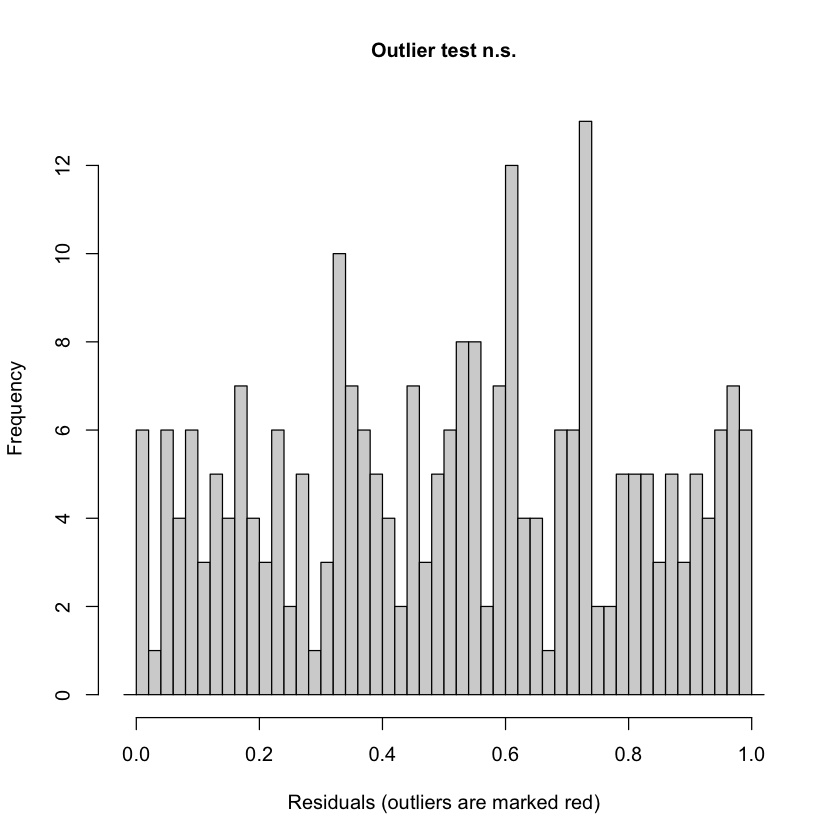


	DHARMa nonparametric dispersion test via sd of residuals fitted vs.
	simulated

data:  simulationOutput
dispersion = 0.00010253, p-value = 0.088
alternative hypothesis: two.sided


County,outbreak,population
<chr>,<int>,<dbl>


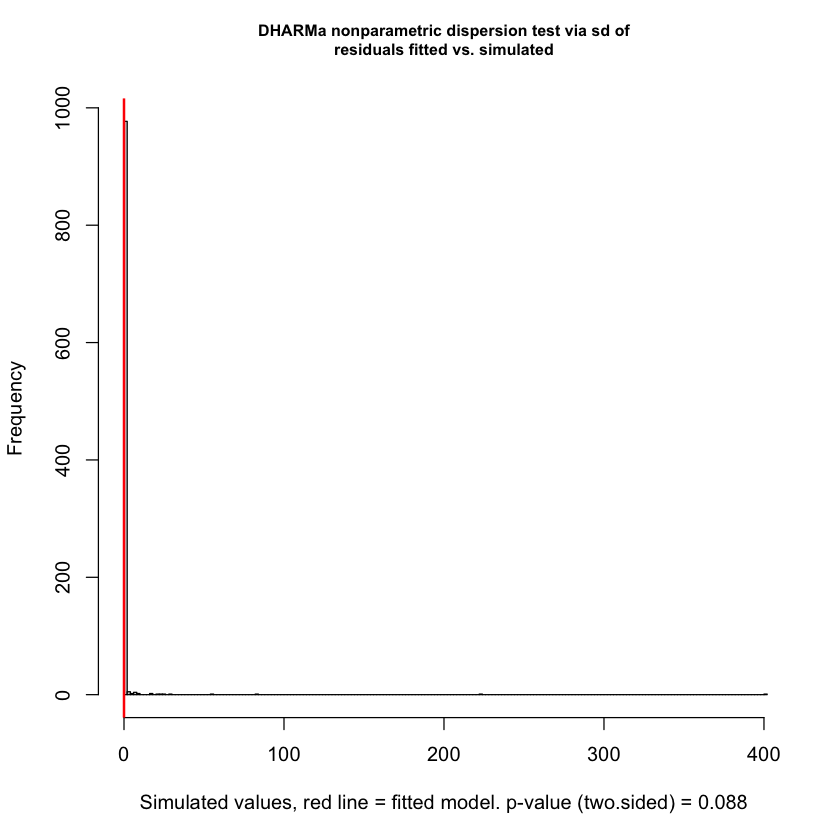

In [31]:
#install.packages("DHARMa")
library(DHARMa)

sim_res <- simulateResiduals(model_final, n = 1000)
plot(sim_res)                          # QQ + residual vs fitted
testOutliers(sim_res)                  # formal outlier test
testDispersion(sim_res)                # check if nbinom2 is enough

# Flag influential counties
outlier_idx <- outliers(sim_res)
county_data[outlier_idx, c("County", "outbreak", "population")]

In [33]:
# Step 1: Find which rows were actually used in the model
model_rows <- as.integer(names(residuals(model_final, type = "pearson")))

# Step 2: Create a subset of county_data that matches the model
county_data_model <- county_data[model_rows, ]

# Step 3: Now safely attach residuals
county_data_model$resid <- residuals(model_final, type = "pearson")

# Step 4: Check which rows were dropped and why
dropped <- county_data[-model_rows, ]
print(dropped)                        # see what's special about rows 62, 160, 161, 162
colSums(is.na(county_data))           # find which columns have NAs

       County  cve outbreak enrollment PHR pct_hispanic pct_black pct_white
62     DeWitt 2.14        0         NA   8           NA        NA        NA
160 McCulloch 1.68        0         NA   9           NA        NA        NA
161  McLennan 1.82        9         NA   7           NA        NA        NA
162  McMullen 8.30        0         NA  11           NA        NA        NA
    pct_poverty pct_uninsured pct_college median_income pct_foreign_born
62           NA            NA          NA            NA               NA
160          NA            NA          NA            NA               NA
161          NA            NA          NA            NA               NA
162          NA            NA          NA            NA               NA
    medical_cost_pct flu_shot_pct pneumonia_shot_pct routine_check_pct
62              18.6         31.6               31.6              76.9
160             16.8         25.2               25.2              76.6
161             13.0         35.4         

County                cve           outbreak         enrollment 
                 0                  0                  0                  5 
               PHR       pct_hispanic          pct_black          pct_white 
                 0                  4                  4                  4 
       pct_poverty      pct_uninsured        pct_college      median_income 
                 4                  4                  4                254 
  pct_foreign_born   medical_cost_pct       flu_shot_pct pneumonia_shot_pct 
                 4                  0                  0                  0 
 routine_check_pct         population   medical_cost_sae 
                 0                  0                  4

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


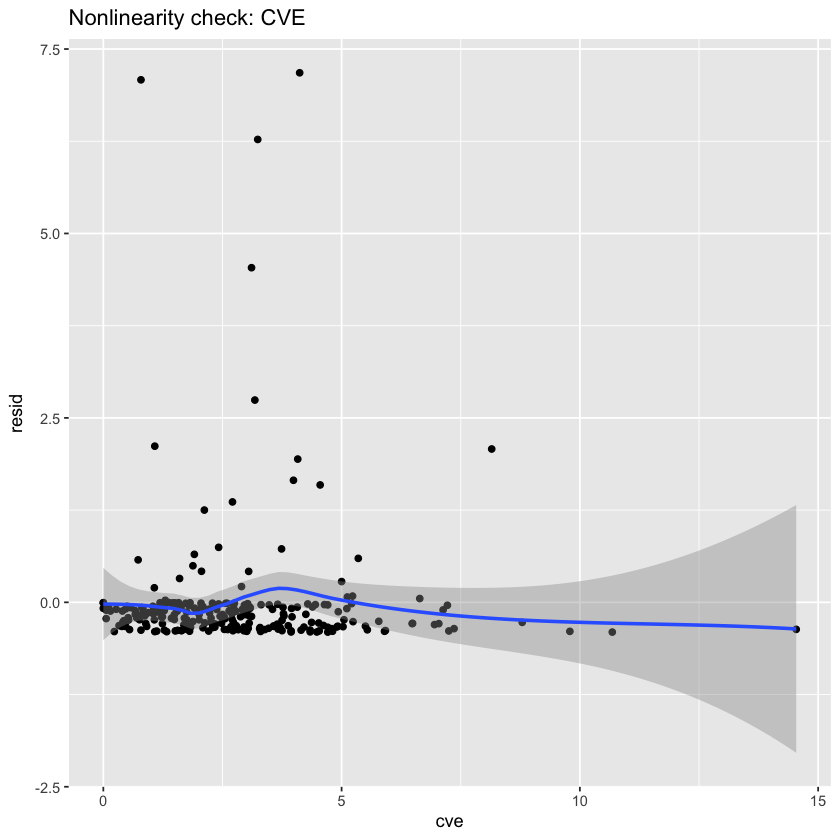

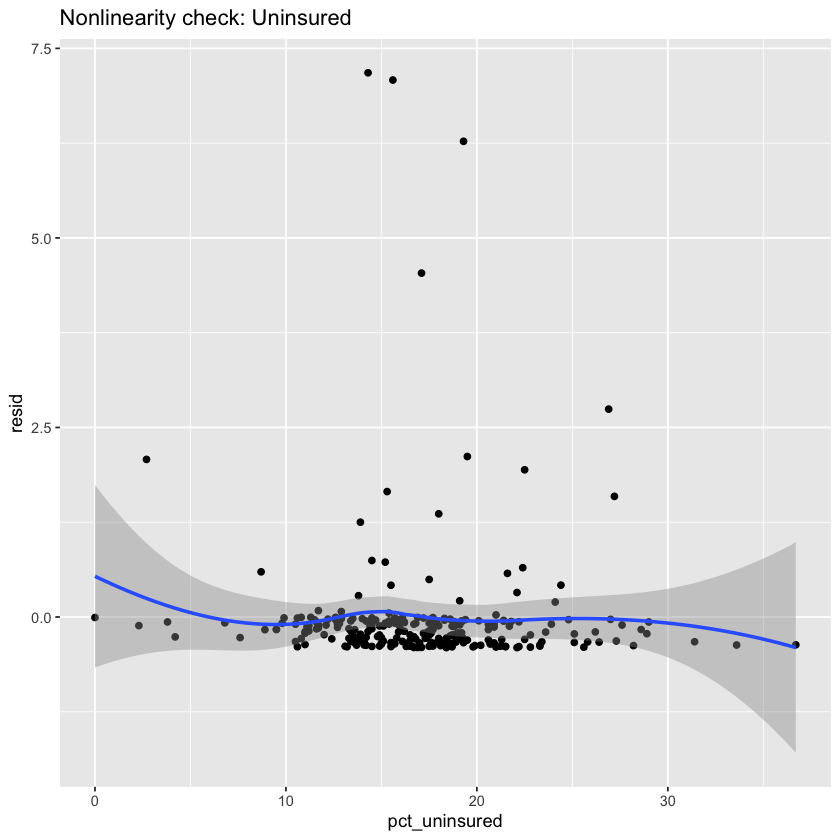

In [34]:
library(ggplot2)

ggplot(county_data_model, aes(x = cve, y = resid)) +
  geom_point() + geom_smooth() +
  labs(title = "Nonlinearity check: CVE")

ggplot(county_data_model, aes(x = pct_uninsured, y = resid)) +
  geom_point() + geom_smooth() +
  labs(title = "Nonlinearity check: Uninsured")

In [35]:
extreme_counties <- county_data_model[county_data_model$resid > 3, ]
print(extreme_counties)

      County  cve outbreak enrollment PHR pct_hispanic pct_black pct_white
74    Fannin 4.12        4       5523   3         13.1       5.9      81.2
99  Hardeman 0.79        1        623   2         25.6       3.4      73.6
140    Lamar 3.24       28       8516   4          9.6      12.1      75.1
156   Martin 3.11        3       1303   9         47.7       2.8      67.2
    pct_poverty pct_uninsured pct_college median_income pct_foreign_born
74          9.1          14.3        19.5            NA              0.7
99          5.1          15.6        16.8            NA              0.7
140        15.7          19.3        21.6            NA              1.9
156         3.5          17.1        20.9            NA              0.0
    medical_cost_pct flu_shot_pct pneumonia_shot_pct routine_check_pct
74              16.6         33.5               33.5              76.8
99              20.9         38.5               38.5              79.3
140             21.6         38.9              

In [36]:
# Does residual variance differ between low/high CVE?
county_data_model$cve_group <- ifelse(county_data_model$cve < 5, "low", "high")
tapply(county_data_model$resid, county_data_model$cve_group, var)

high       low 
0.2391504 0.9065990

In [38]:
model_disp <- update(model_final,
  dispformula = ~ scale(cve))   # dispersion varies with CVE

AIC(model_final, model_disp)
summary(model_disp)

,df,AIC
,<dbl>,<dbl>
model_final,8,375.2864
model_disp,9,377.1162


 Family: nbinom2  ( log )
Formula:          
outbreak ~ scale(cve) + scale(pct_uninsured) + scale(pct_hispanic) +  
    scale(pct_black) + scale(medical_cost_pct) + offset(log(population)) +  
    (1 | PHR)
Dispersion:                ~scale(cve)
Data: county_data

      AIC       BIC    logLik -2*log(L)  df.resid 
    377.1     408.8    -179.6     359.1       241 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 PHR    (Intercept) 3.739    1.934   
Number of obs: 250, groups:  PHR, 11

Conditional model:
                        Estimate Std. Error z value Pr(>|z|)    
(Intercept)             -12.8480     0.8385 -15.322   <2e-16 ***
scale(cve)                1.0138     0.5678   1.786   0.0742 .  
scale(pct_uninsured)      0.6209     0.3494   1.777   0.0756 .  
scale(pct_hispanic)       0.5109     0.5331   0.958   0.3380    
scale(pct_black)         -0.7330     0.4766  -1.538   0.1240    
scale(medical_cost_pct)   2.3108     0.9412   2.455   0.0141 *  
---
Sign

In [39]:
model_no_extreme <- update(model_final,
  data = county_data_model[county_data_model$resid <= 3, ])

# Compare coefficients — do your main findings hold?
cbind(
  main    = fixef(model_final)$cond,
  trimmed = fixef(model_no_extreme)$cond
)

,main,trimmed
(Intercept),-12.8328655,-13.7922507
scale(cve),0.8341470,1.2512199
scale(pct_uninsured),0.5695910,0.0678434
scale(pct_hispanic),0.4996862,1.6343973
scale(pct_black),-0.7557011,-0.7074841
scale(medical_cost_pct),2.3092284,2.4484991


In [40]:
extreme_counties[, c("pct_uninsured")]

[1] 14.3 15.6 19.3 17.1

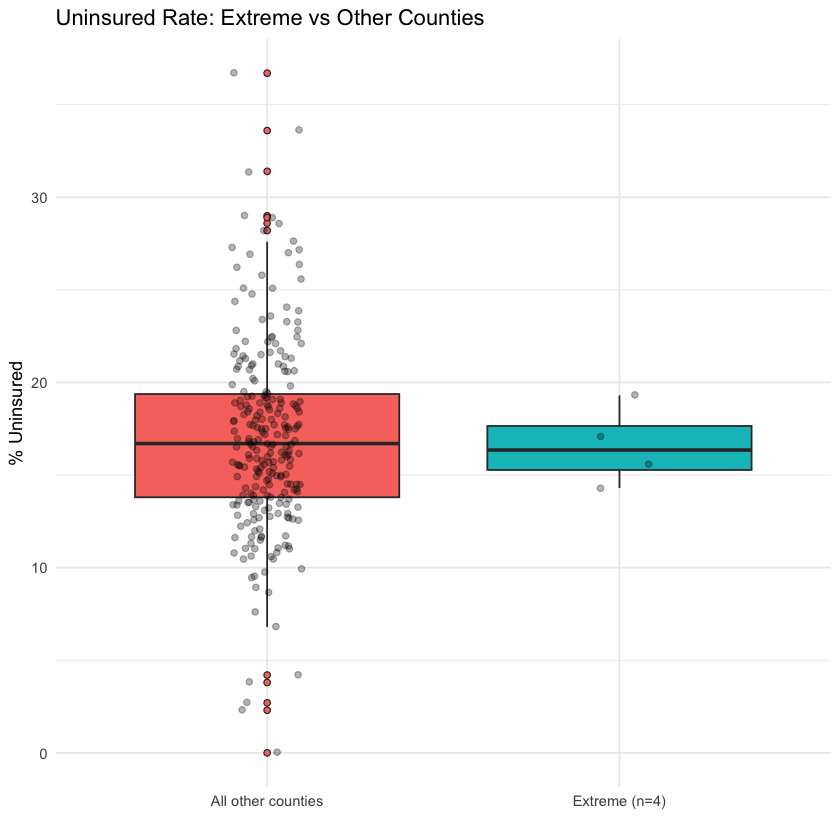

In [41]:
library(ggplot2)

county_data_model$group <- ifelse(county_data_model$resid > 3, 
                                   "Extreme (n=4)", 
                                   "All other counties")

ggplot(county_data_model, aes(x = group, y = pct_uninsured, fill = group)) +
  geom_boxplot(outlier.shape = 21) +
  geom_jitter(width = 0.1, alpha = 0.3) +
  labs(title = "Uninsured Rate: Extreme vs Other Counties",
       x = "", y = "% Uninsured") +
  theme_minimal() +
  theme(legend.position = "none")